# Lecture 12

## Convolutional neural networks using Pytorch

For image data, including medical images, convolutional neural networks are widely used. In this class, we will cover:
- the basics of convolutional neural networks and how to implement them in PyTorch
- how to load a pretrained network and use it on your own data

This will also be a good opportunity to learn about debugging in VS Code.

Convolutional neural networks consist of four main types of operations:

- Convolutions: these apply small learnable filters, or kernels, across the image to detect local patterns such as edges, textures, and shapes
- Pooling: this reduces the size of the image
- Nonlinear activation functions: these introduce nonlinearity into the network. A common choice is the ReLU activation function.
- Fully connected layers: these combine the extracted features and map them to the final output

<div style="text-align: center;">
  <img src="https://media.geeksforgeeks.org/wp-content/uploads/20260217113409515144/working_of_cnn__.webp" width="600">
</div>

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision

First, download MedNIST data.

In [77]:
# pip install medmnist
from medmnist import PneumoniaMNIST
train_ds = PneumoniaMNIST(split="train", download=True, root='data')
test_ds = PneumoniaMNIST(split="test", download=True, root='data')

In [78]:
print(train_ds.imgs.shape)
print(test_ds.imgs.shape)

label_names = train_ds.labels
label_names

(4708, 28, 28)
(624, 28, 28)


array([[1],
       [1],
       [1],
       ...,
       [1],
       [0],
       [1]], shape=(4708, 1), dtype=uint8)

In [79]:
batch_size = 128


transform = torchvision.transforms.ToTensor()
train_X = torch.stack([transform(x) for x in
                            train_ds.imgs])
test_X = torch.stack([transform(x) for x in
                            test_ds.imgs])
train_tns = TensorDataset(train_X,
                            torch.tensor(train_ds.labels, dtype=torch.float))
test_tns = TensorDataset(test_X,
                            torch.tensor(test_ds.labels, dtype=torch.float))

train_loader = DataLoader(train_tns, batch_size=batch_size)
test_loader = DataLoader(test_tns, batch_size=1000)

# note that torch requires image tensors to be [N, C, H, W]
# N: samples, C: channels, H: height, W: width

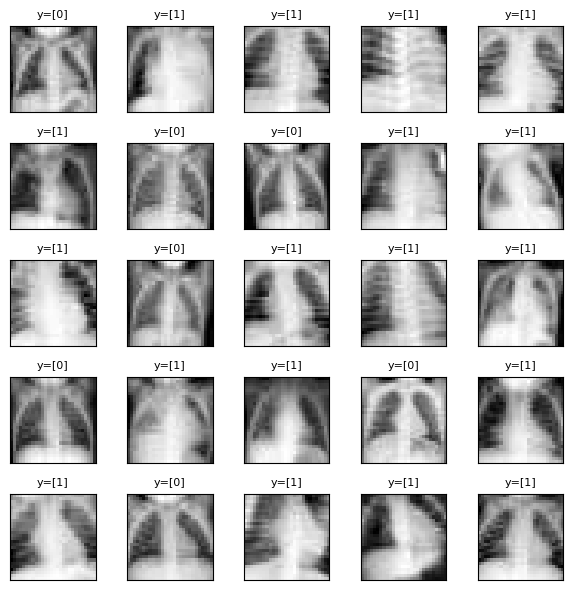

In [80]:
fig, axes = plt.subplots(5, 5, figsize=(6, 6))
rng = np.random.default_rng(4)
indices = rng.choice(np.arange(len(train_tns)), 25,
                     replace=False).reshape((5, 5))

for i in range(5):
    for j in range(5):
        idx = indices[i, j]
        axes[i, j].imshow(
            train_X[idx][0],
            cmap="gray",
            interpolation=None
        )
        axes[i, j].set_title(f"y={train_ds.labels[idx]}", fontsize=8)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout()

In [81]:
conv_layer = nn.Conv2d(in_channels=1,
                              out_channels=1,
                              kernel_size=(3,3),
                              padding='same')
print(conv_layer.bias)
print(conv_layer.weight)

Parameter containing:
tensor([0.2494], requires_grad=True)
Parameter containing:
tensor([[[[ 0.0395,  0.1605, -0.1467],
          [-0.0531,  0.3014,  0.1850],
          [ 0.0375, -0.2089,  0.1813]]]], requires_grad=True)


In [82]:
kernel = torch.tensor([
    [[[-1., -1., -1.],
      [-1.,  8., -1.],
      [-1., -1., -1.]]]
])  # shape [1, 1, 3, 3]

# kernel = torch.tensor([
#     [[[1., 2., 1.],
#       [2., 4., 2.],
#       [1., 2., 1.]]]
# ], dtype=torch.float32) / 16

with torch.no_grad():
    conv_layer.weight.copy_(kernel)
    conv_layer.bias.copy_(torch.tensor([0]))

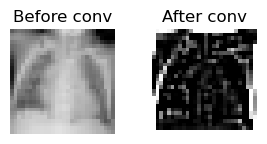

In [83]:
x = train_X[0][0]          # shape: [H, W]
x_in = x.unsqueeze(0).unsqueeze(0)  # shape: [1, 1, H, W] 

# apply convolution
y = conv_layer(x_in)                # shape: [1, C_out, H_out, W_out]

# plot input and first output channel
fig, axes = plt.subplots(1, 2, figsize=(3, 1.5))

axes[0].imshow(x.cpu(), cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Before conv")
axes[0].axis("off")

axes[1].imshow(y[0, 0].detach().cpu(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("After conv")
axes[1].axis("off")

plt.tight_layout()
plt.show()


Let's set up our convolutional neural network.

In [84]:
class BuildingBlock(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels):
        super(BuildingBlock, self).__init__()

        self.conv = nn.Conv2d(in_channels=in_channels,
                              out_channels=out_channels,
                              kernel_size=(3,3),
                              padding='same')
        self.activation = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2,2))

    def forward(self, x):
        x_out = self.conv(x)
        x_out = self.activation(x_out)
        x_out = self.pool(x_out)
        return x_out

class ConvModel(nn.Module):

    def __init__(self):
        super(ConvModel, self).__init__()

        self.conv1 = BuildingBlock(1, 32)
        self.conv2 = BuildingBlock(32, 64)

        self.output = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(7 * 7 * 64, 100),
            nn.ReLU(),
            nn.Linear(100, 1)
        )

    def forward(self, x):
        val = self.conv1(x)
        val = self.conv2(val)

        val = torch.flatten(val, start_dim=1)
        return self.output(val)


Let's instantiate our CNN model

In [85]:
model = ConvModel()

In [86]:
y_pred = model(x_in)
print(y_pred)

tensor([[-0.0610]], grad_fn=<AddmmBackward0>)


In [87]:
loss_fn = torch.nn.BCEWithLogitsLoss(reduction="sum") # Binary Cross Entropy loss, checks how far your predictions are from true values


lr = 0.001
epochs = 100

optimizer = optim.Adam(model.parameters(), lr=lr)

# set model to training mode
model.train()

for epoch in range(epochs):
    epoch_loss = 0

    for x_batch, y_batch in train_loader:

        y_pred = model(x_batch)
        loss = loss_fn(y_pred, y_batch)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()

    if epoch % 10 == 0:
        print('epoch: ', epoch, 'loss:', f"{epoch_loss:.3}")


epoch:  0 loss: 2.46e+03
epoch:  10 loss: 5.22e+02
epoch:  20 loss: 4.23e+02
epoch:  30 loss: 3.35e+02
epoch:  40 loss: 2.71e+02
epoch:  50 loss: 2.52e+02
epoch:  60 loss: 1.82e+02
epoch:  70 loss: 1.51e+02
epoch:  80 loss: 1.21e+02
epoch:  90 loss: 1.29e+02


We save the trained model so we can access it later.

In [88]:
filename = 'xray-model.pt'
torch.save(model.state_dict(), filename)

Load model:

In [89]:
model.load_state_dict(torch.load(filename))

<All keys matched successfully>

Let's calculate the accuracy of the model on a subset of the data.

In [90]:
model.eval()
x_batch, y_batch = next(iter(train_loader))

with torch.no_grad():
    logits_pred = model(x_batch)
    probs_pred = torch.sigmoid(logits_pred)
    y_pred = (probs_pred > 0.5).long()
    acc = (y_pred == y_batch.long()).float().mean()

print(acc.item())

0.9921875


In [91]:
model.eval()
x_batch, y_batch = next(iter(test_loader))

with torch.no_grad():
    logits_pred = model(x_batch)
    probs_pred = torch.sigmoid(logits_pred)
    y_pred = (probs_pred > 0.5).long()
    acc = (y_pred == y_batch).float().mean()

print(acc.item())

0.8605769276618958



Let's look at some examples the model got right and wrong:

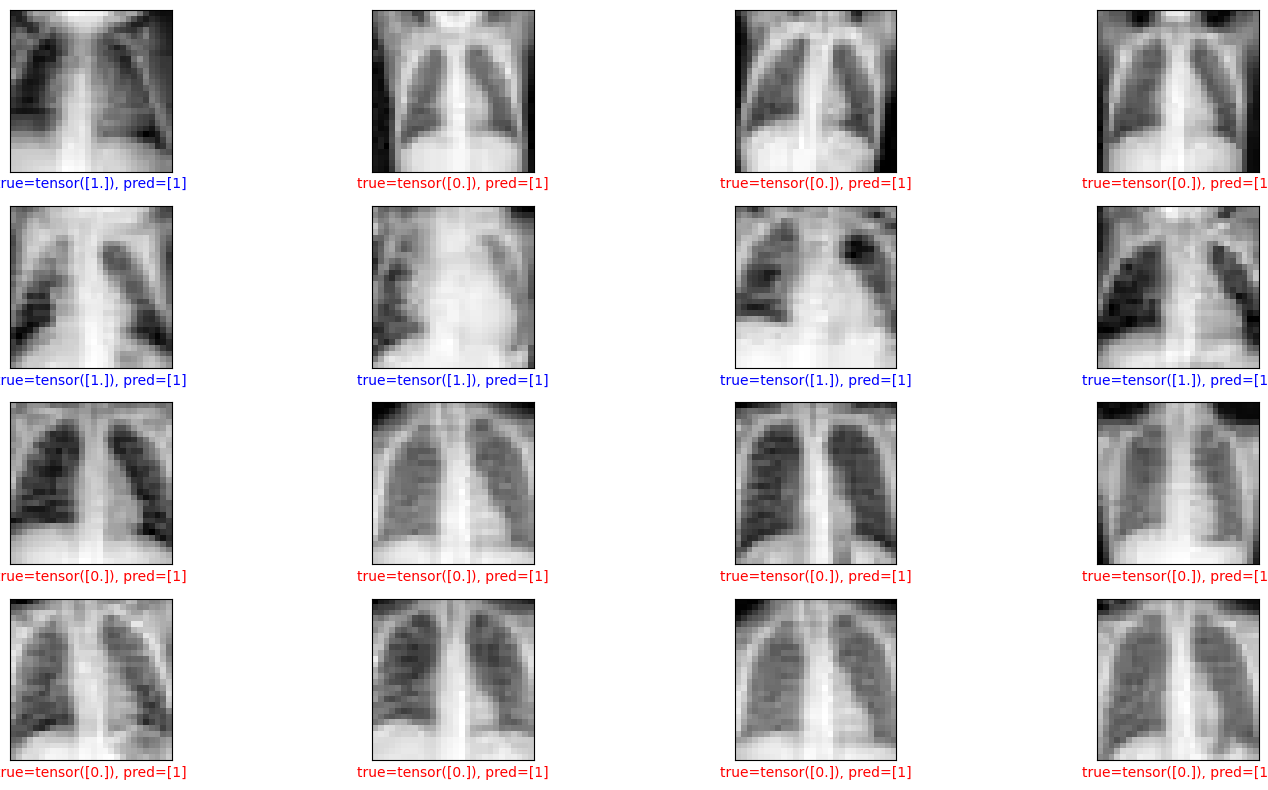

In [92]:
correct =  torch.where(y_pred == y_batch)[0]
errors = torch.where(y_pred != y_batch)[0]
inds1 = np.random.choice(correct.numpy(), size = 8)
inds2 = np.random.choice(errors.numpy(), size = 8)
inds = np.concatenate((inds1, inds2))

pred_array = y_pred.detach().numpy()

num_rows = 4
num_cols = 4
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
    n = inds[i]
    plt.subplot(num_rows, num_cols, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image, label = x_batch[n], y_batch[n]

    plt.imshow(np.transpose(image,
                        [1, 2, 0]),
           interpolation=None, cmap="gray")
    plt.xlabel(label)
    predicted_label = label_names[y_pred[n]]
    if predicted_label == label:
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel("true={}, pred={}".format(
        label,
        predicted_label),
        color=color)
    

plt.tight_layout() 


### ResNet

The `torchvision.models` package provides pre-trained models like ResNet-50 (a ResNet model with 50 layers). (Note this uses code from https://github.com/intro-stat-learning/ISLP_labs/blob/stable/Ch10-deeplearning-lab.ipynb)

ResNet takes an input image and outputs predicted scores or probabilities for a set of classes.

- **Input:** an image, for example a \(224 \times 224 \times 3\) color image
- **Output:** a vector of class scores, one for each possible category (1000 classes)

### Here we apply ResNet to one or more images of your choice, which you should store in img_examples/

In [93]:
from torchvision.models import (resnet50, ResNet50_Weights)
from torchvision.transforms import (Resize,
                                    Normalize,
                                    CenterCrop,
                                    ToTensor)
from torchvision.io import read_image
from glob import glob
import json
import pandas as pd

In [94]:
resnet_model = resnet50(weights=ResNet50_Weights.DEFAULT)

In [95]:
# We need to normalize the images for use for ResNet-50

resize = Resize((232,330), antialias=True)
crop = CenterCrop(224)
normalize = Normalize([0.485,0.456,0.406],
                      [0.229,0.224,0.225])
imgfiles = sorted([f for f in glob('img_examples/*')])
imgs = torch.stack([torch.div(crop(resize(read_image(f))), 255)
                    for f in imgfiles])
imgs_no_norm = imgs
imgs = normalize(imgs)
imgs.size()

torch.Size([1, 3, 224, 224])

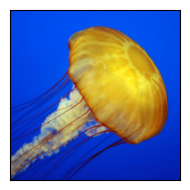

In [96]:
plt.figure(figsize=(2 * len(imgfiles), 2))

for i, imgfile in enumerate(imgfiles):
    plt.subplot(1, len(imgfiles), i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(np.transpose(imgs_no_norm[i].numpy(),
                        [1, 2, 0]),
           interpolation=None)
    

plt.tight_layout() 

In [97]:
resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [98]:
img_preds = resnet_model(imgs)

In [99]:
# apply softmax to the outputs of the ResNet
img_probs = np.exp(np.asarray(img_preds.detach()))
img_probs /= img_probs.sum(1)[:,None]

In [100]:
labels = ResNet50_Weights.DEFAULT.meta["categories"]

class_labels = pd.DataFrame({
    "idx": range(len(labels)),
    "label": labels
}).set_index("idx")
class_labels

,label
idx,
0,tench
1,goldfish
2,great white shark
3,tiger shark
4,hammerhead
...,...
995,earthstar
996,hen-of-the-woods
997,bolete


In [101]:
for i, imgfile in enumerate(imgfiles):
    img_df = class_labels.copy()
    img_df['prob'] = img_probs[i]
    img_df = img_df.sort_values(by='prob', ascending=False)[:3]
    print(f'Image: {imgfile}')
    print(img_df.reset_index().drop(columns=['idx']))

Image: img_examples/Jelly_cc11.jpg
       label      prob
0  jellyfish  0.335069
1   mushroom  0.001836
2     orange  0.001595
